In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

In [2]:
df = pd.read_csv('monthly_milk_production.csv', index_col=False)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [3]:
df.shape

(168, 1)

In [4]:
df.isnull().sum()

Production    0
dtype: int64

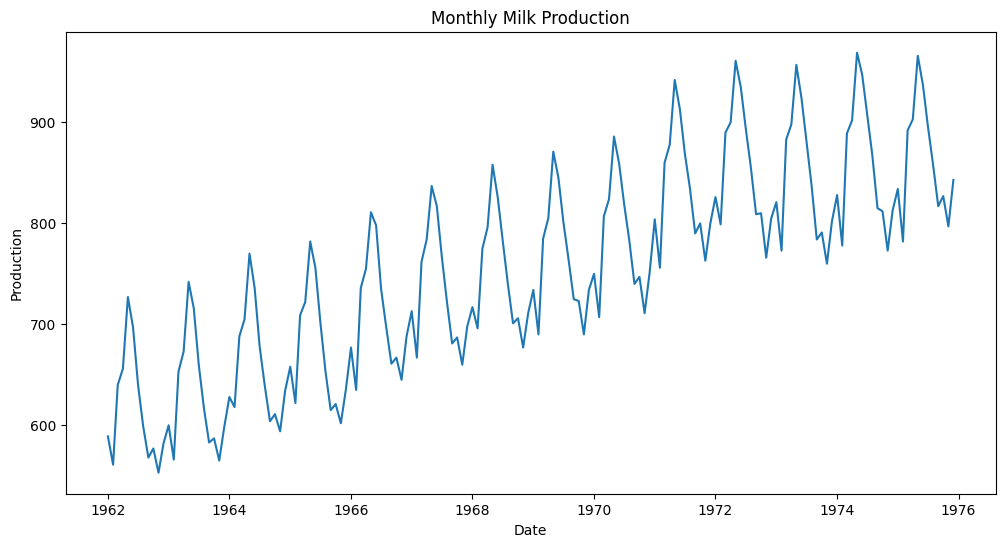

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['Production'])
plt.title('Monthly Milk Production')
plt.xlabel('Date')
plt.ylabel('Production')
plt.show()

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Production']])

In [7]:
def create_sequences(data, seq_length=12):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

x, y = create_sequences(scaled_data, 12)
x.shape, y.shape

((156, 12, 1), (156, 1))

In [8]:
train_size = len(x) - 12
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
x_train.shape, x_test.shape

((144, 12, 1), (12, 12, 1))

In [9]:
x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [10]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 64, 1, batch_first=True)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [11]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, 1, batch_first=True)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [12]:
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 64, 1, batch_first=True)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [13]:
def train_model(model, epochs=150):
    opt = optim.Adam(model.parameters(), lr=0.001)
    crit = nn.MSELoss()
    for e in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(x_train_t)
        loss = crit(out, y_train_t)
        loss.backward()
        opt.step()
    return model

In [14]:
rnn = train_model(RNNModel())
lstm = train_model(LSTMModel())
gru = train_model(GRUModel())

In [15]:
def get_predictions(model, data_tensor):
    model.eval()
    with torch.no_grad():
        pred = model(data_tensor).numpy()
    return scaler.inverse_transform(pred)

In [16]:
pred_rnn = get_predictions(rnn, x_test_t)
pred_lstm = get_predictions(lstm, x_test_t)
pred_gru = get_predictions(gru, x_test_t)
y_true = scaler.inverse_transform(y_test)

In [17]:
def mape(true, pred):
    return np.mean(np.abs((true - pred) / true)) * 100

def evaluate_predictions(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    m = mape(true, pred)
    print(f"{name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {m:.4f}%")
    return mae, rmse, m

metrics_rnn = evaluate_predictions(y_true, pred_rnn, 'RNN')
metrics_lstm = evaluate_predictions(y_true, pred_lstm, 'LSTM')
metrics_gru = evaluate_predictions(y_true, pred_gru, 'GRU')

RNN - MAE: 27.4641, RMSE: 31.5282, MAPE: 3.2086%
LSTM - MAE: 51.6484, RMSE: 58.9687, MAPE: 5.9421%
GRU - MAE: 38.9176, RMSE: 47.5322, MAPE: 4.4712%


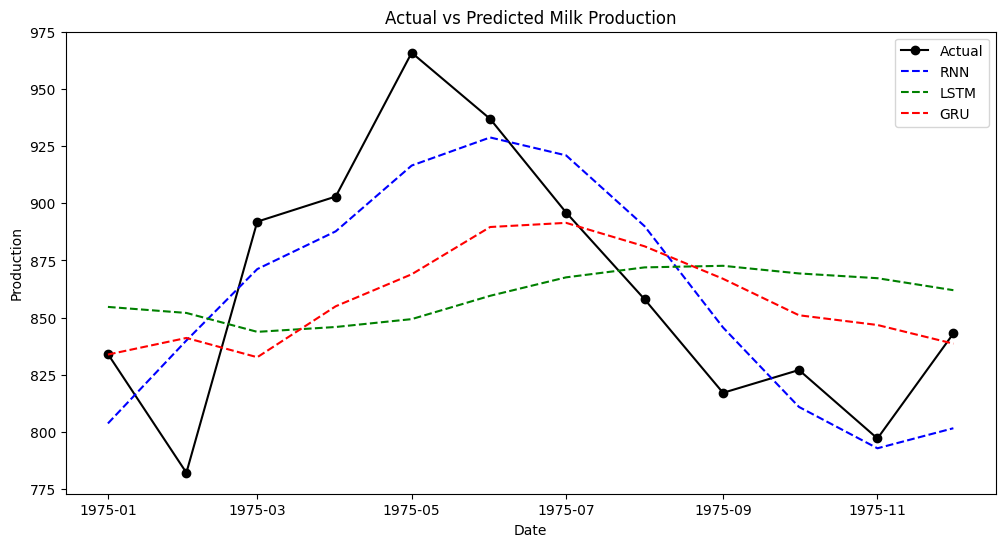

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df.index[-12:], y_true, label='Actual', color='black', marker='o')
plt.plot(df.index[-12:], pred_rnn, label='RNN', color='blue', linestyle='--')
plt.plot(df.index[-12:], pred_lstm, label='LSTM', color='green', linestyle='--')
plt.plot(df.index[-12:], pred_gru, label='GRU', color='red', linestyle='--')
plt.title('Actual vs Predicted Milk Production')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()

In [19]:
def forecast_future(model, last_window, steps=12):
    model.eval()
    curr_window = list(last_window)
    forecasts = []
    for _ in range(steps):
        inp = torch.FloatTensor(np.array([curr_window]))
        with torch.no_grad():
            pred = model(inp).item()
        forecasts.append(pred)
        curr_window.pop(0)
        curr_window.append([pred])
    return scaler.inverse_transform(np.array(forecasts).reshape(-1, 1))

In [20]:
last_window = scaled_data[-12:]
future_rnn = forecast_future(rnn, last_window)
future_lstm = forecast_future(lstm, last_window)
future_gru = forecast_future(gru, last_window)

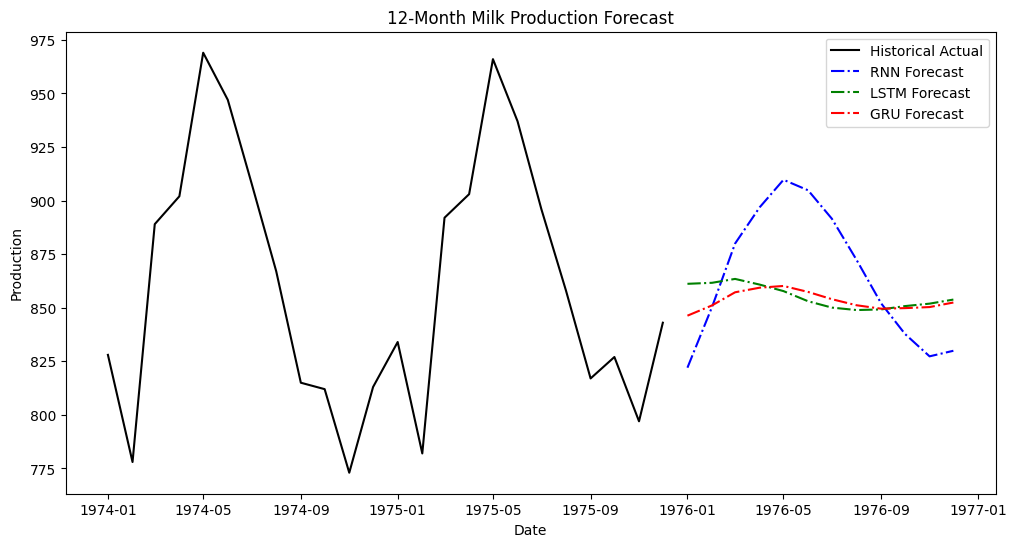

In [21]:
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
plt.figure(figsize=(12, 6))
plt.plot(df.index[-24:], df['Production'].iloc[-24:], label='Historical Actual', color='black')
plt.plot(future_dates, future_rnn, label='RNN Forecast', color='blue', linestyle='-.')
plt.plot(future_dates, future_lstm, label='LSTM Forecast', color='green', linestyle='-.')
plt.plot(future_dates, future_gru, label='GRU Forecast', color='red', linestyle='-.')
plt.title('12-Month Milk Production Forecast')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()